# Seasonal Agriculture Performance Analysis Project

## Project Goal

To analyze how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in crop performance, resource usage and economic outcomes.


## Problem Statement

**Agricultural performance can vary across seasons due to differences in environmental conditions, farming practices, resource usage and market conditions. This project analyzes the given agricultural dataset to identify seasonal differences, patterns, relationships and unusual observations in agricultural performance.**

## Project Objectives

The main objectives of this project are to:

- Understand and prepare the agricultural dataset.
- Analyze agricultural performance across seasons.
- Identify seasonal patterns and trends.
- Examine relationships between environmental conditions and agricultural outcomes.
- Compare crops and irrigation methods across seasons.
- Analyze resource usage and economic performance.
- Identify important findings and unusual observations.
- Provide evidence-based recommendations and conclusions.


## Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, resource usage and economic performance.

It contains **4,000 records and 28 variables**, covering **3 seasons, 8 crops and 4 irrigation methods**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
# View a random sample of 5 records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [9]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [10]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [11]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [12]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_percentage
})

missing_table[missing_table["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


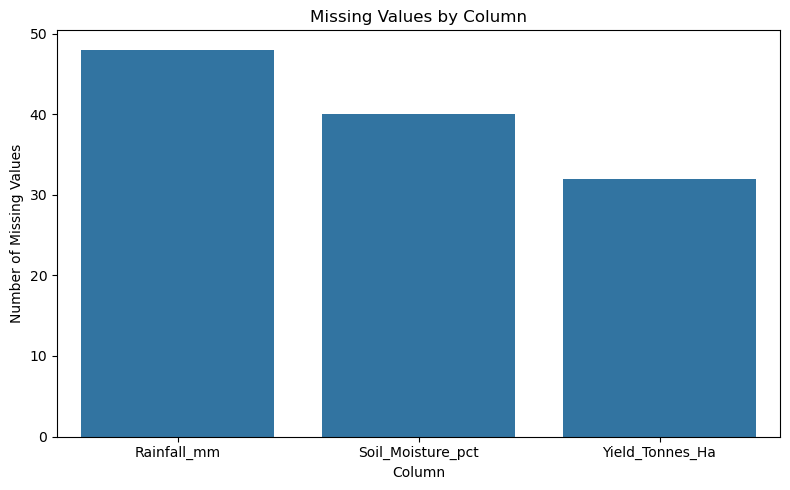

In [14]:
# Visualize columns containing missing values

missing_plot = missing_values[missing_values > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", "="*50)
    print(col)
    print(df[col].value_counts())


Farm_ID
Farm_ID
SF10001    1
SF12672    1
SF12659    1
SF12660    1
SF12661    1
          ..
SF11339    1
SF11340    1
SF11341    1
SF11342    1
SF14000    1
Name: count, Length: 4000, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count,

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [18]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [19]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [20]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

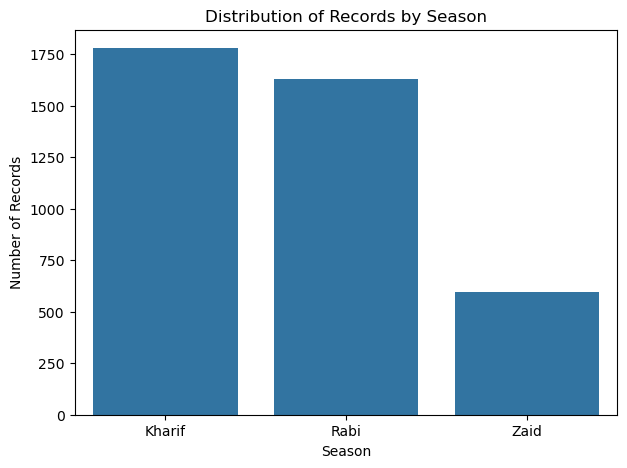

In [21]:
# Distribution of records by season

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

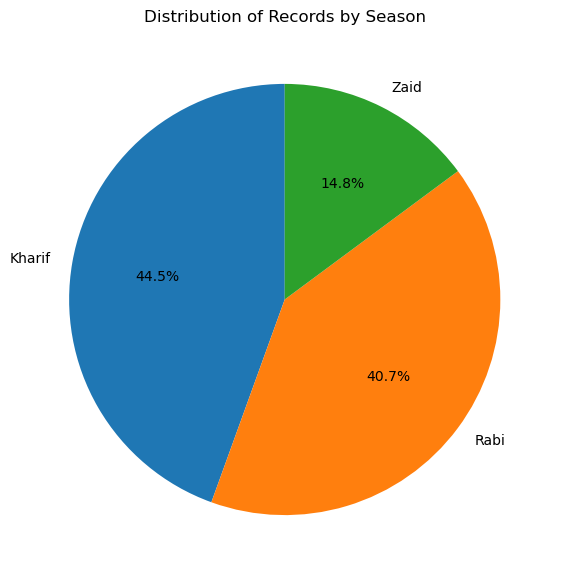

In [22]:
# Percentage distribution of records by season

plt.figure(figsize=(7, 7))

df["Season"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)

plt.title("Distribution of Records by Season")
plt.ylabel("")

plt.show()

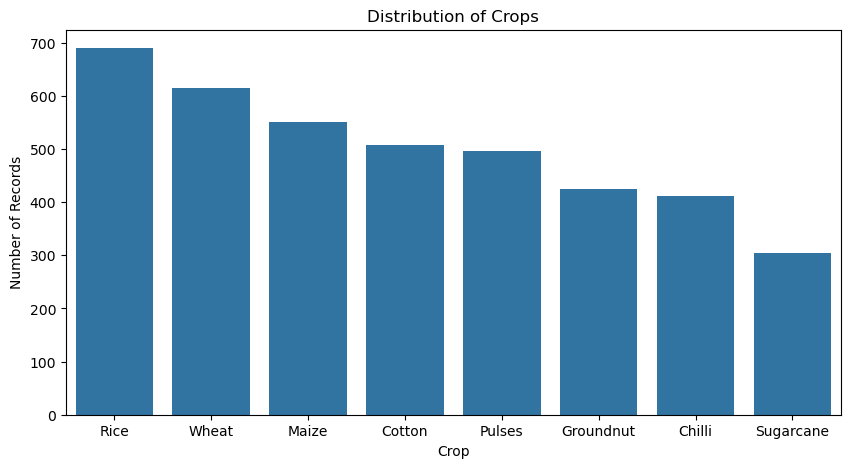

In [23]:
# Distribution of crops

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks()

plt.show()

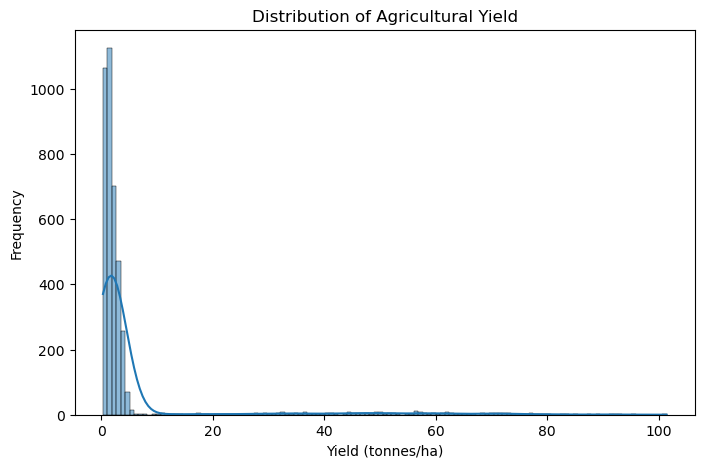

In [24]:
# Distribution of agricultural yield

plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")

plt.show()

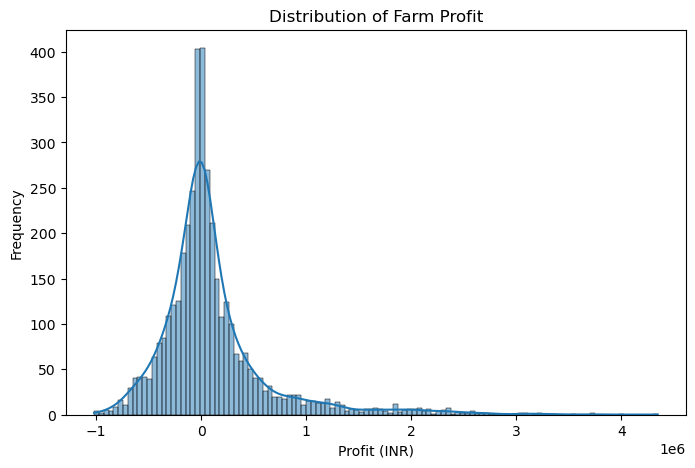

In [25]:
# Distribution of farm profit

plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="Profit_INR",kde=True)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.show()

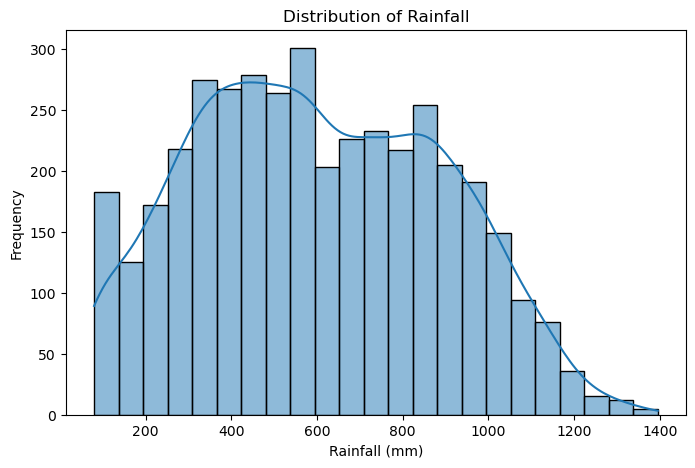

In [26]:
# Distribution of rainfall

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Rainfall_mm", kde=True)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

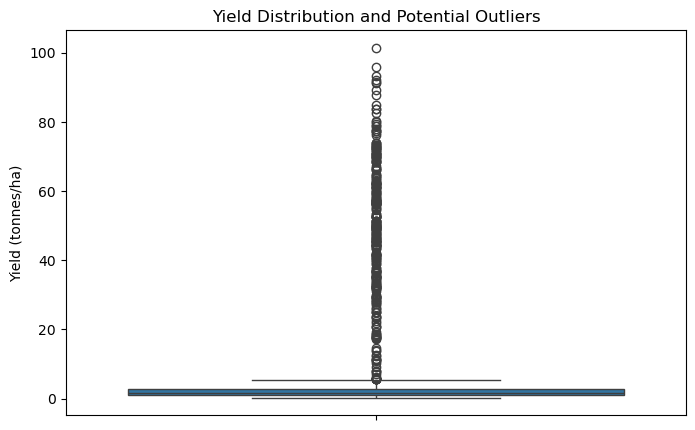

In [27]:
# Check yield distribution and potential outliers

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, y="Yield_Tonnes_Ha")

plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")

plt.show()

In [28]:
Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_limit) |
    (df["Yield_Tonnes_Ha"] > upper_limit)
]

print("Number of potential yield outliers:", len(outliers))

Number of potential yield outliers: 302


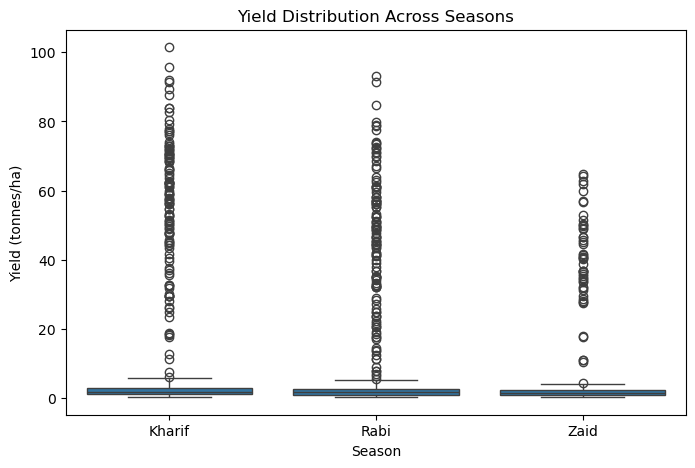

In [29]:
# Yield distribution across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")

plt.show()

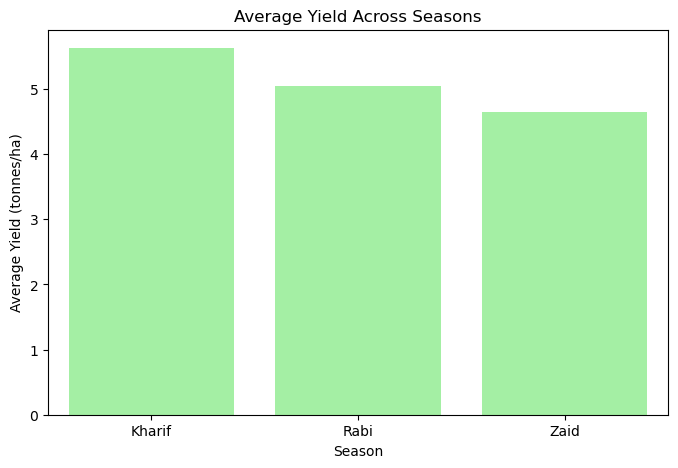

In [48]:
# Average yield across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    errorbar=None, 
    color="palegreen"
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")

plt.show()

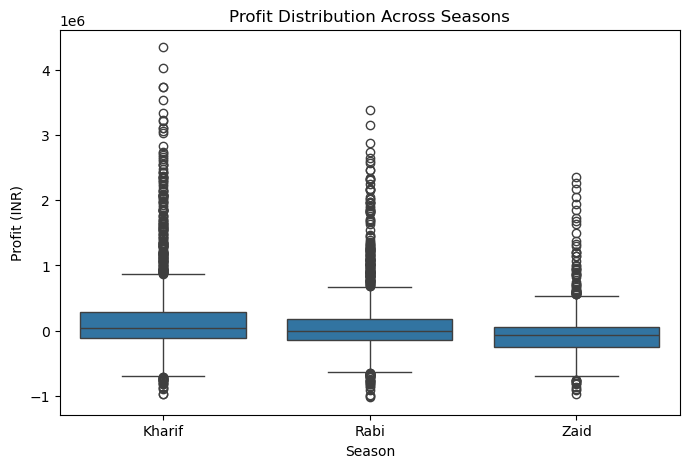

In [31]:
# Profit distribution across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

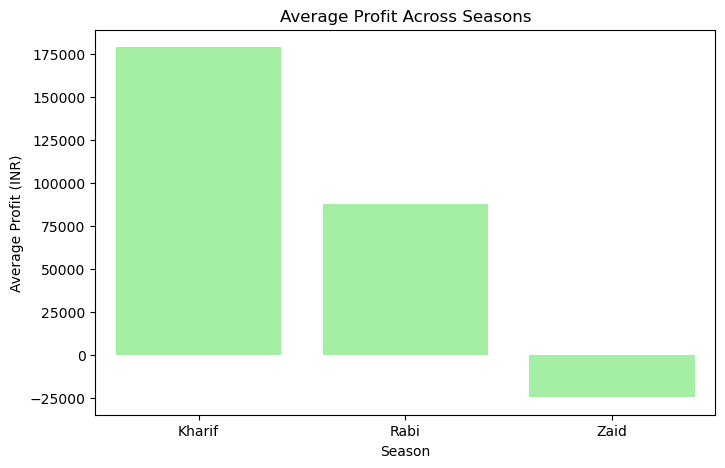

In [ ]:
# Average profit across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    errorbar=None, 
    color="palegreen"
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

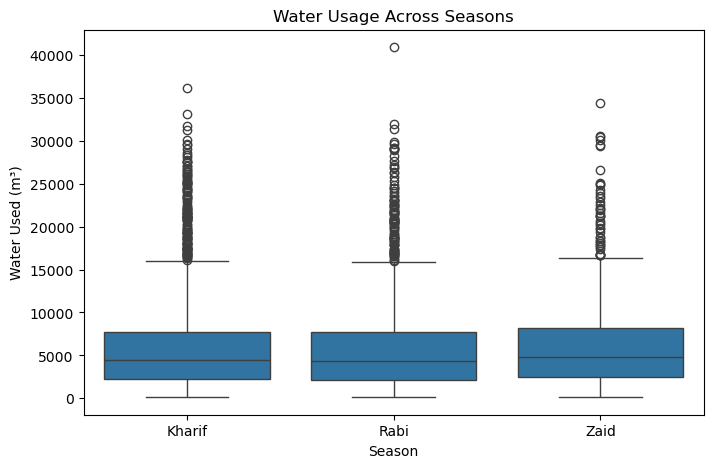

In [33]:
# Water usage across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Water_Used_m3"
)

plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

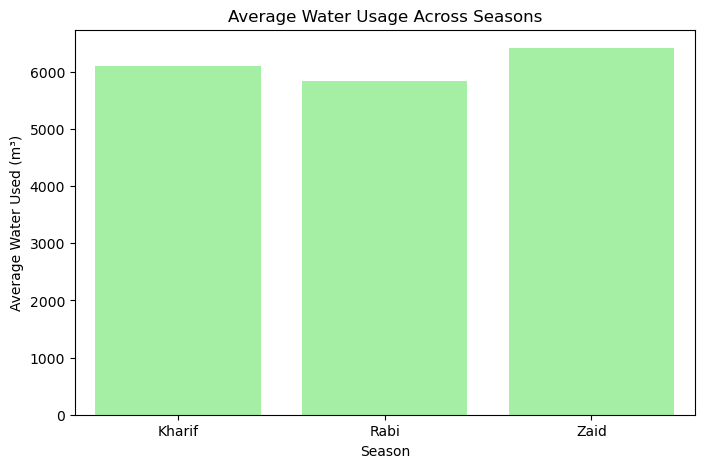

In [49]:
# Average water usage across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    errorbar=None, 
    color="palegreen"
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.show()

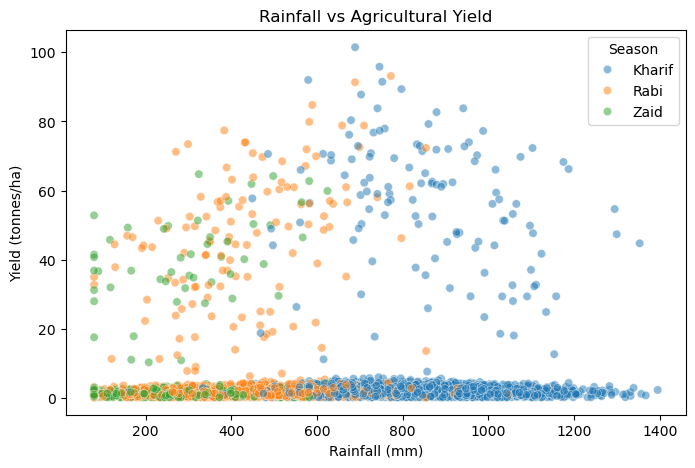

In [35]:
# Relationship between rainfall and yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.5
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")

plt.show()

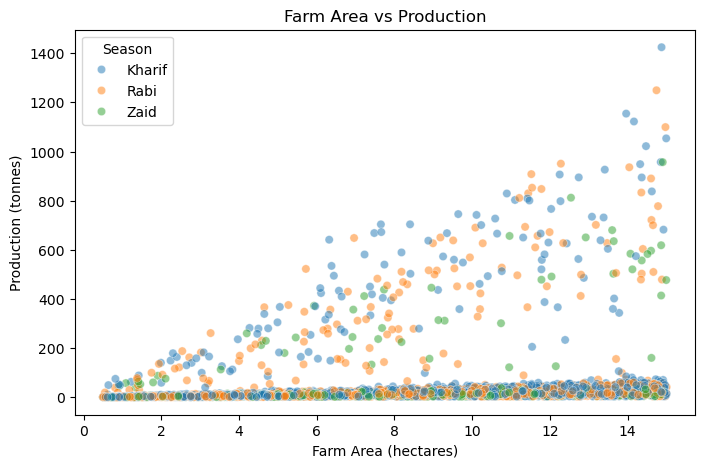

In [36]:
# Relationship between farm area and production

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season",
    alpha=0.5
)

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.legend(title="Season")

plt.show()

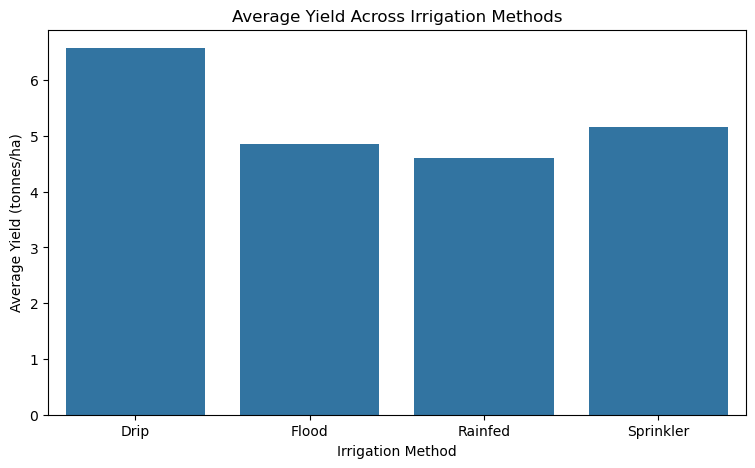

In [37]:
# Average yield across irrigation methods

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield Across Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")

plt.show()

In [ ]:
# Calculate negative and non-negative profit percentages
profit_status = df.groupby('Season')['Profit_INR'].apply(
    lambda x: pd.Series({
        'Negative Profit': (x < 0).mean() * 100,
        'Non-Negative Profit': (x >= 0).mean() * 100
    })
).unstack()

profit_status

,Negative Profit,Non-Negative Profit
Season,,
Kharif,42.214727,57.785273
Rabi,51.137062,48.862938
Zaid,64.478114,35.521886


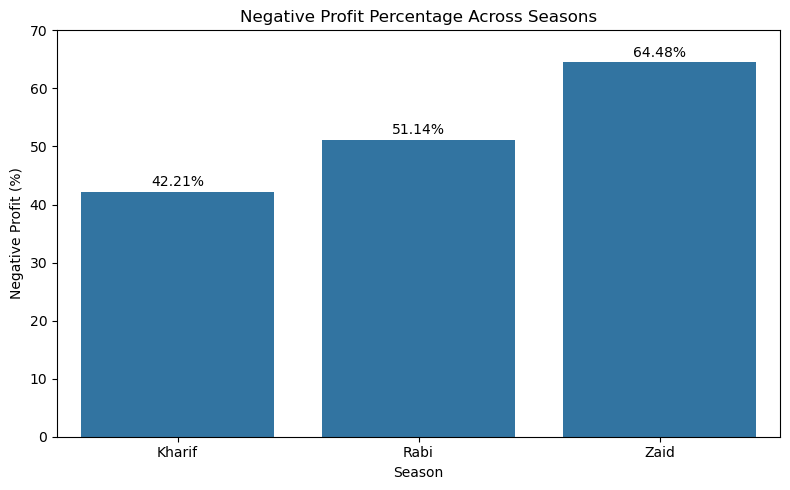

In [76]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=negative_profit,
    x='Season',
    y='Negative_Profit_Percentage'
)

plt.title('Negative Profit Percentage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Negative Profit (%)')
plt.ylim(0, 70)

for i, value in enumerate(negative_profit['Negative_Profit_Percentage']):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.show()

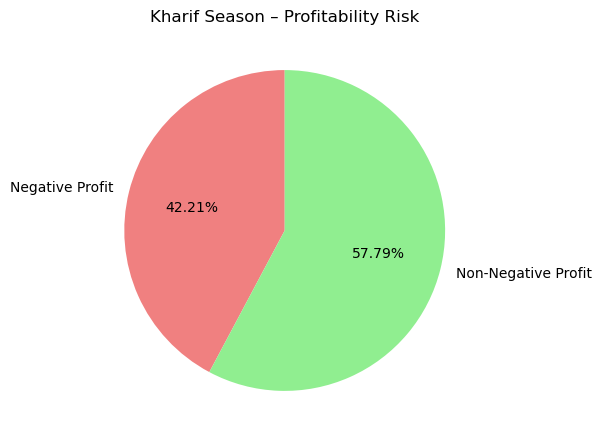

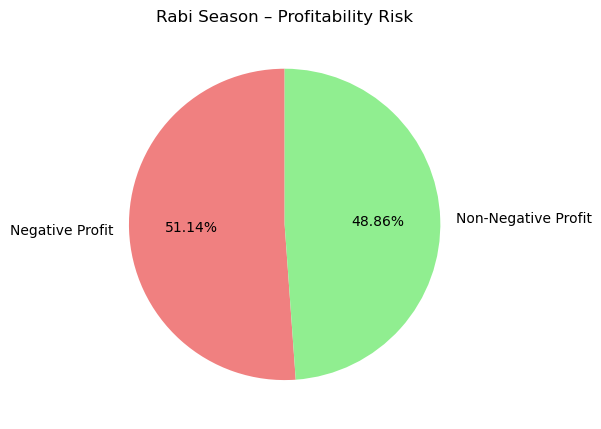

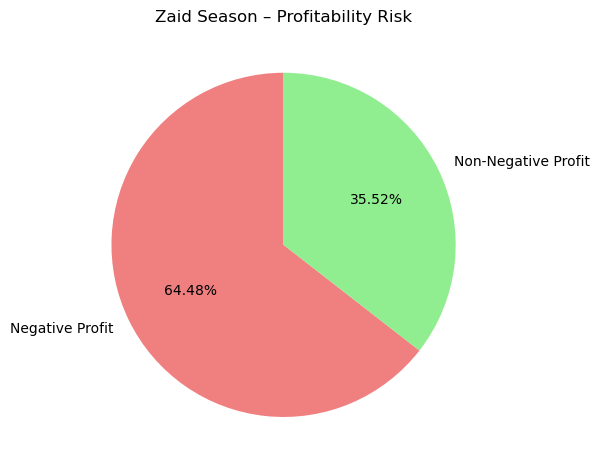

In [80]:
for season in ['Kharif', 'Rabi', 'Zaid']:
    
    plt.figure(figsize=(6, 6))
    
    plt.pie(
        profit_status.loc[season],
        labels=profit_status.columns,
        autopct='%1.2f%%',
        startangle=90,
        colors=['lightcoral', 'lightgreen']

    )
    
    plt.title(f'{season} Season – Profitability Risk')
    plt.tight_layout()
    plt.show()

In [39]:
# Average yield by crop and season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(
          ["Season", "Average_Yield"],
          ascending=[True, False]
      )
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.47       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.20       107343.59                      1.94
       Pulses              0.88       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.29      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.20       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.96       -53925.34                      1.49
       Pulses              0.67      -139227.81                      1.95

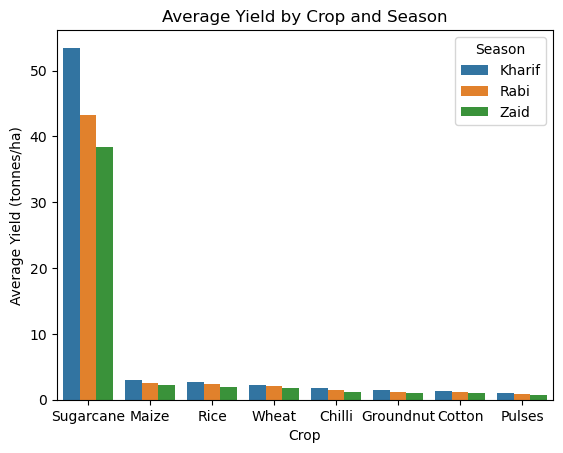

In [55]:
# Compare average yield by crop and season

plt.figure()

sns.barplot(
    data=crop_season_summary.reset_index(),
    x="Crop",
    y="Average_Yield",
    hue="Season",
    errorbar=None
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks()
plt.legend(title="Season")

plt.show()

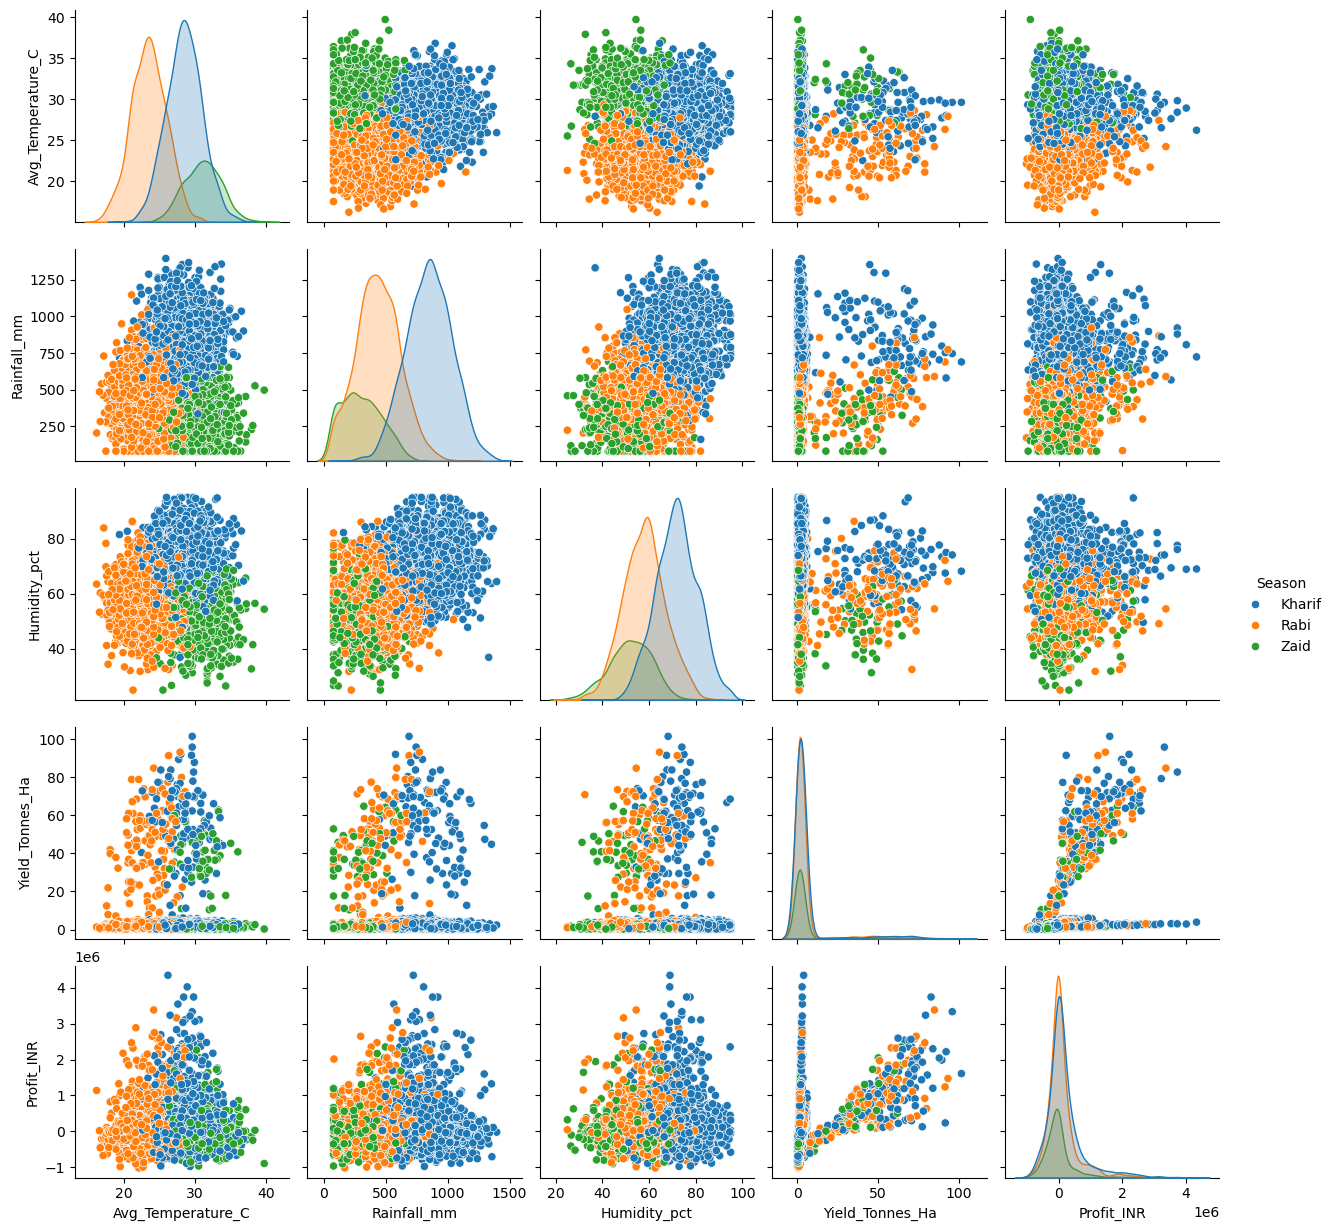

In [41]:
# Compare important environmental and performance variables

selected_columns = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    df[selected_columns],
    hue="Season"
)

plt.show()

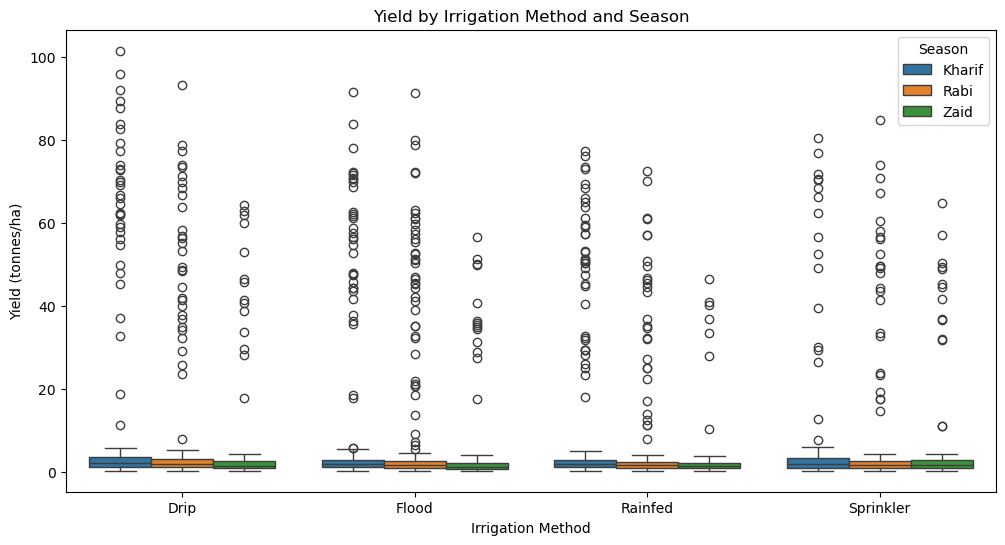

In [ ]:
# Compare yield by irrigation method and season

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")

plt.show()

C:\Users\aditi\AppData\Local\Temp\ipykernel_33320\2117511846.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  sns.barplot(


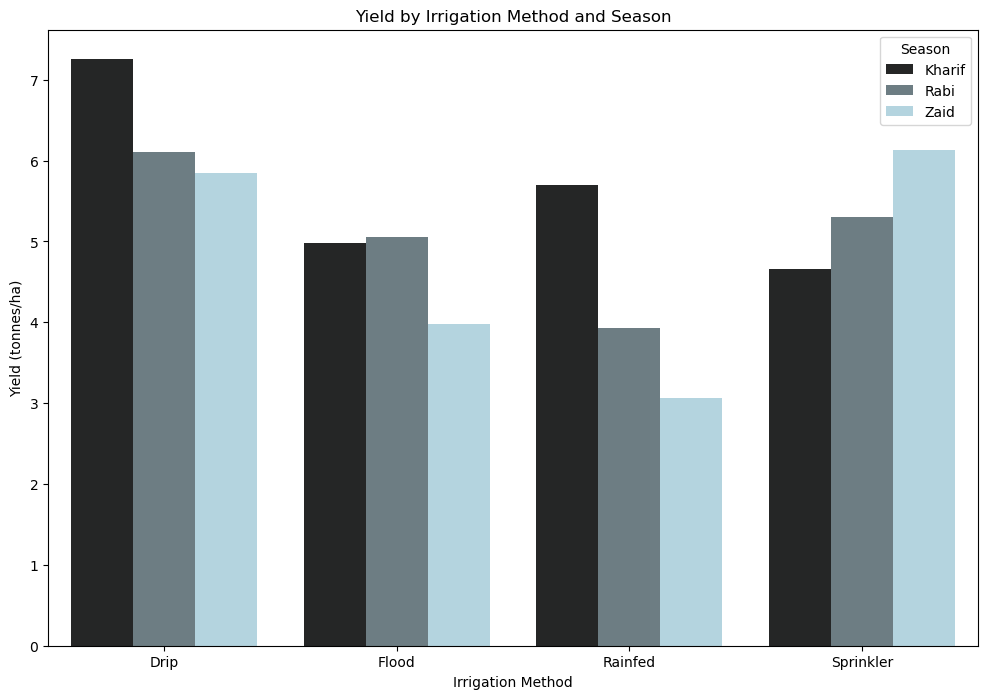

In [70]:
# Compare yield by irrigation method and season

plt.figure(figsize=(12, 8))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season",
    errorbar=None,
    color="lightblue"
)

plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")

plt.show()

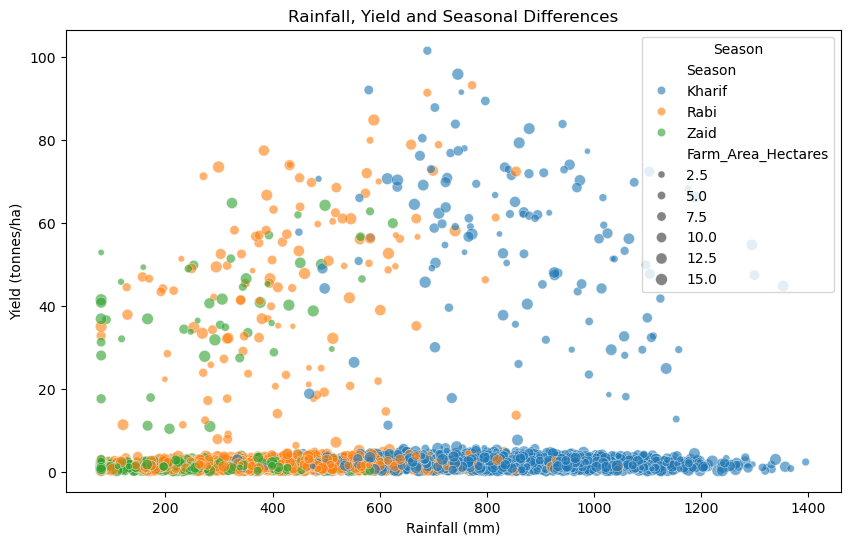

In [43]:
# Examine rainfall, yield and season together

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    alpha=0.6
)

plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")

plt.show()

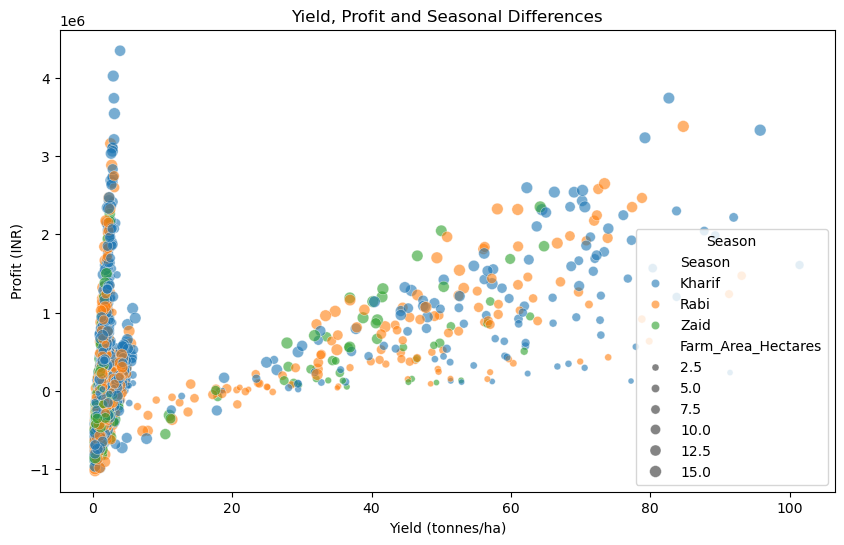

In [44]:
# Examine yield, profit and season together

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    alpha=0.6
)

plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.legend(title="Season")

plt.show()

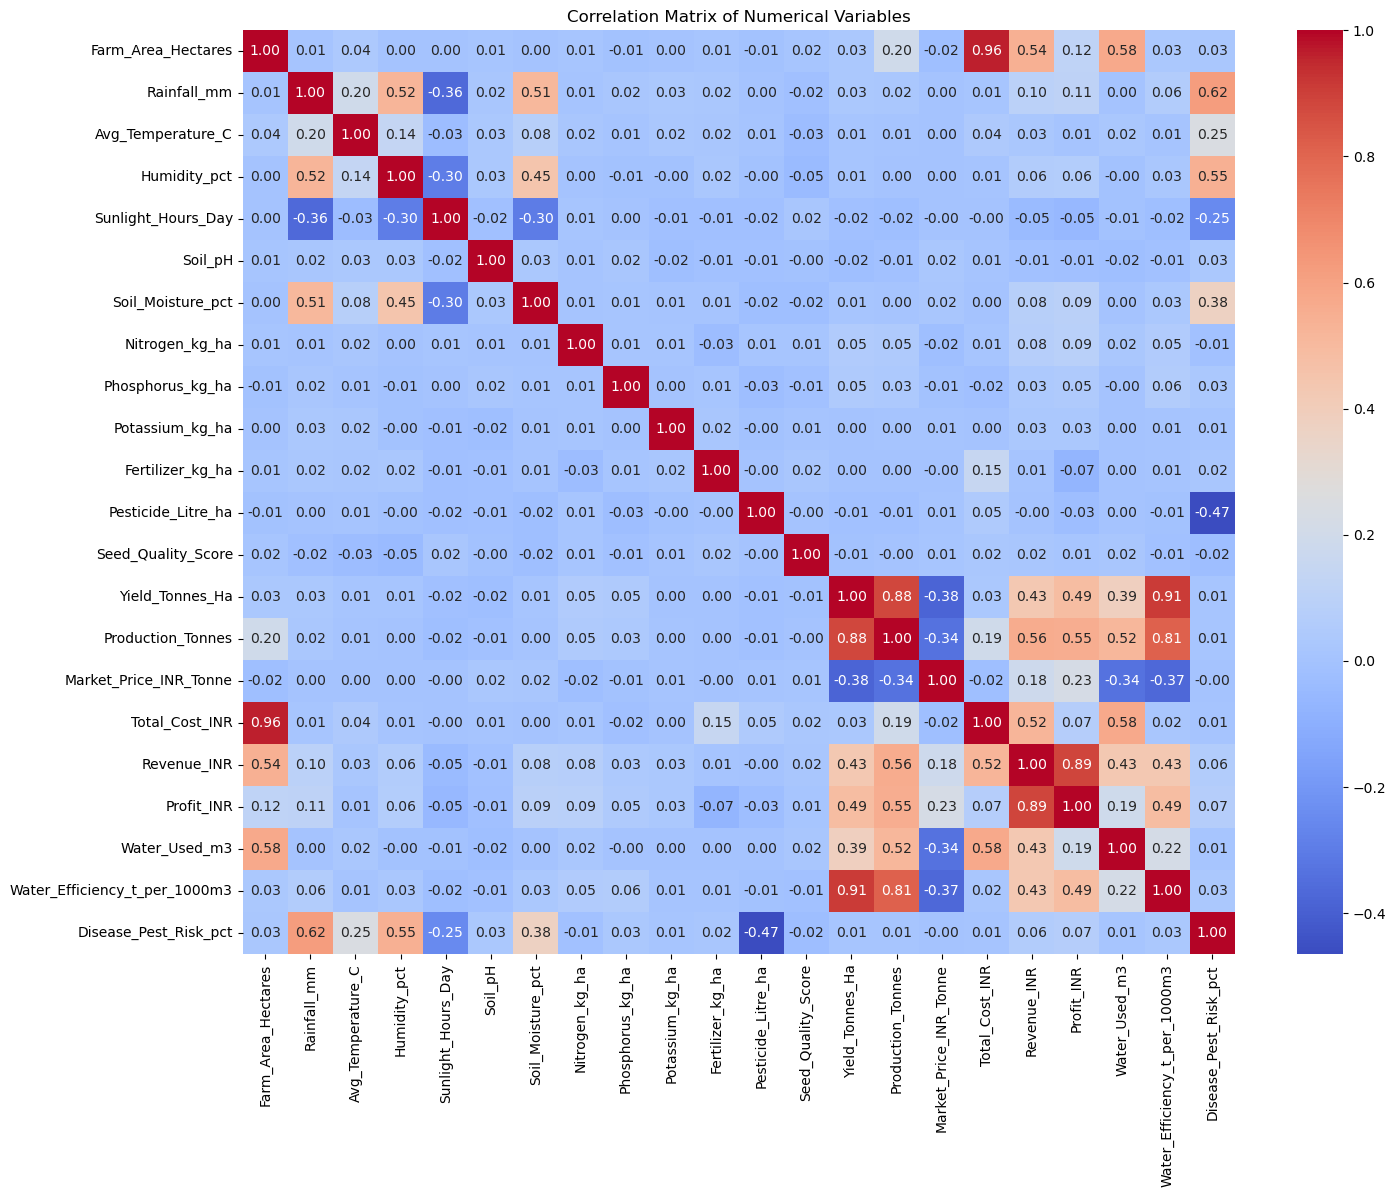

In [45]:
# Correlation analysis of numerical variables

corr = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [46]:
# Compare important performance measures across seasons

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Disease_Pest_Risk
Season,,,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20,5.89,54.47
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99,5.19,40.48
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89,4.41,38.22


## Key Insights

1. **Kharif showed the strongest overall performance**, with the highest average yield and average profit among the three seasons.

2. **Zaid showed the weakest profitability**, with negative average profit and the highest proportion of negative-profit records.

3. **Zaid had the highest average water usage**, while Rabi had the lowest average water usage.

4. **Yield and water-use efficiency showed a strong positive relationship** (correlation = 0.913).

5. **Yield and production showed a strong positive relationship** (correlation = 0.883).

6. **Crop performance varied across seasons**, with many crops showing higher average yield in Kharif and lower yield in Zaid.

7. **Irrigation performance varied by season**. Drip irrigation showed the highest average profit in Kharif and Rabi, while Sprinkler showed the highest average profit in Zaid.

8. **Profit was strongly related to revenue** (correlation = 0.887), while its relationship with yield was moderate (0.488), indicating that profitability depends on more than yield alone.

9. **Negative-profit records were common across all seasons**, with the highest proportion in Zaid (64.48%).

10. **302 potential yield outliers were identified** using the IQR method. These observations were retained because they may represent genuine variation and require further investigation rather than automatic removal.

## Recommendations

* Improve water-use management, particularly in seasons with higher water consumption.
* Evaluate irrigation methods separately for different seasons.
* Consider crop-season combinations when planning agricultural activities.
* Monitor profitability using revenue, cost, market price, production and yield together.
* Investigate records with negative profit to identify possible areas of improvement.
* Examine unusual yield observations further before deciding whether they should be removed.

## Limitations

* The dataset may not represent all agricultural regions.
* Missing values were handled using median imputation.
* Potential outliers were identified but not removed.
* The number of records differs across seasons.
* Correlation indicates association and does not establish causation.
* Profitability can be influenced by several factors not fully captured in the analysis.
* The project is descriptive and does not provide predictive modelling.

## Conclusion

This project analyzed **4,000 agricultural records across 28 variables** to understand seasonal variations in agricultural performance. The analysis showed clear differences among Kharif, Rabi and Zaid seasons in terms of yield, profit, production and water usage.

Kharif showed the strongest overall performance, while Zaid showed comparatively higher profitability risk. Crop and irrigation performance also varied across seasons. Correlation analysis highlighted strong relationships between yield and water-use efficiency, yield and production, and profit and revenue.

Overall, the analysis demonstrates that agricultural performance should be evaluated by considering **season, crop, irrigation, resource usage and economic factors together**. The findings provide useful evidence for seasonal planning and resource management, while further analysis with larger, multi-year and more regionally diverse datasets could provide deeper insights.